# Neuronales Netz – Sentimentanalyse von Produktrezensionen

Trainiert ein feedforward neuronales Netz auf TF-IDF-Features zur Klassifikation von Amazon-Rezensionen (1–5 Sterne).

**Split:** 70/15/15 (Train / Validation / Test)

**Daten:** `data/splits/train_0_50000_70_15_15.jsonl` etc.

## 1. Imports

In [10]:
import json
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ============================================================
# KONFIGURATION: Project Root
# ============================================================
PROJECT_ROOT = Path("../")

DATA_DIR   = PROJECT_ROOT / "data" / "splits"
TRAIN_FILE = DATA_DIR / "train_0_50000_70_15_15.jsonl"
VAL_FILE   = DATA_DIR / "val_0_50000_70_15_15.jsonl"
TEST_FILE  = DATA_DIR / "test_0_50000_70_15_15.jsonl"

MODEL_DIR   = PROJECT_ROOT / "results" / "neural" / "models"
METRICS_DIR = PROJECT_ROOT / "results" / "neural" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "results" / "neural" / "figures"

for d in [MODEL_DIR, METRICS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

print(f"PROJECT_ROOT: {PROJECT_ROOT.resolve()}")
print(f"TRAIN_FILE existiert: {TRAIN_FILE.exists()}")
print(f"VAL_FILE   existiert: {VAL_FILE.exists()}")
print(f"TEST_FILE  existiert: {TEST_FILE.exists()}")
print(f"TensorFlow Version: {tf.__version__}")
print("✓ Imports und Pfade initialisiert")

PROJECT_ROOT: C:\Develop\Python\nlp
TRAIN_FILE existiert: True
VAL_FILE   existiert: True
TEST_FILE  existiert: True
TensorFlow Version: 2.20.0
✓ Imports und Pfade initialisiert


## 2. Hyperparameter-Konfiguration

Alle tuningwürdigen Parameter zentral an einer Stelle.

| Parameter | Beschreibung | Typische Werte |
|---|---|---|
| `HIDDEN_UNITS` | Neuronen je Hidden Layer | 64 – 512 |
| `DROPOUT_RATE` | Dropout-Rate zur Regularisierung | 0.0 – 0.5 |
| `LEARNING_RATE` | Lernrate des Optimierers | 0.0001 – 0.01 |
| `BATCH_SIZE` | Batch-Größe beim Training | 32 – 256 |
| `EPOCHS` | Max. Trainingsepochen | 10 – 50 |
| `MAX_FEATURES` | Max. Anzahl TF-IDF-Features | 1.000 – 100.000 |
| `MIN_DF` | Min. Dokumenthäufigkeit eines Terms | 1 – 10 |
| `MAX_DF` | Max. Dokumenthäufigkeit eines Terms | 0.7 – 1.0 |
| `NGRAM_RANGE` | Uni- und/oder Bigramme | (1,1), (1,2) |
| `STOP_WORDS` | Stoppwörter entfernen | 'english', None |
| `SUBLINEAR_TF` | Logarithmische TF-Skalierung | True, False |

In [11]:
# ============================================================
# HYPERPARAMETER – hier anpassen!
# ============================================================

# Netzarchitektur
HIDDEN_UNITS  = 256     # Neuronen je Hidden Layer
DROPOUT_RATE  = 0.3     # Dropout-Rate zur Regularisierung
LEARNING_RATE = 0.001   # Lernrate des Adam-Optimierers

# Training
BATCH_SIZE = 128        # Batch-Größe
EPOCHS     = 20         # Max. Trainingsepochen (Early Stopping greift ggf. früher)

# TF-IDF Vektorizer
MAX_FEATURES = 10000    # Anzahl der Features (Vokabular-Größe)
MIN_DF       = 2        # Term muss in mind. N Dokumenten vorkommen
MAX_DF       = 0.95     # Term darf in höchstens X% der Dokumente vorkommen
NGRAM_RANGE  = (1, 2)   # (1,1) = Unigramme; (1,2) = Uni- + Bigramme
STOP_WORDS   = 'english'  # Stoppwörter: 'english' oder None
SUBLINEAR_TF = False    # True = log(TF) statt TF; oft besser bei langen Texten

print("Aktuelle Hyperparameter:")
print(f"  HIDDEN_UNITS  = {HIDDEN_UNITS}")
print(f"  DROPOUT_RATE  = {DROPOUT_RATE}")
print(f"  LEARNING_RATE = {LEARNING_RATE}")
print(f"  BATCH_SIZE    = {BATCH_SIZE}")
print(f"  EPOCHS        = {EPOCHS}")
print(f"  MAX_FEATURES  = {MAX_FEATURES}")
print(f"  MIN_DF        = {MIN_DF}")
print(f"  MAX_DF        = {MAX_DF}")
print(f"  NGRAM_RANGE   = {NGRAM_RANGE}")
print(f"  STOP_WORDS    = {STOP_WORDS}")
print(f"  SUBLINEAR_TF  = {SUBLINEAR_TF}")

Aktuelle Hyperparameter:
  HIDDEN_UNITS  = 256
  DROPOUT_RATE  = 0.3
  LEARNING_RATE = 0.001
  BATCH_SIZE    = 128
  EPOCHS        = 20
  MAX_FEATURES  = 10000
  MIN_DF        = 2
  MAX_DF        = 0.95
  NGRAM_RANGE   = (1, 2)
  STOP_WORDS    = english
  SUBLINEAR_TF  = False


## 3. Daten laden

In [12]:
def load_data(filepath):
    """Lädt JSONL-Datei und kombiniert title + text."""
    texts, ratings = [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            texts.append(f"{data['title']} {data['text']}")
            ratings.append(int(data['rating']))
    return texts, ratings

print("Lade Trainingsdaten ...")
X_train_texts, y_train_raw = load_data(TRAIN_FILE)
print(f"  Train:      {len(X_train_texts):>7,} Samples")

print("Lade Validierungsdaten ...")
X_val_texts, y_val_raw = load_data(VAL_FILE)
print(f"  Validation: {len(X_val_texts):>7,} Samples")

print("Lade Testdaten ...")
X_test_texts, y_test_raw = load_data(TEST_FILE)
print(f"  Test:       {len(X_test_texts):>7,} Samples")

Lade Trainingsdaten ...
  Train:      140,000 Samples
Lade Validierungsdaten ...
  Validation:  30,000 Samples
Lade Testdaten ...
  Test:        30,000 Samples


## 4. TF-IDF Vektorisierung & Label-Encoding

In [13]:
print("Vektorisierung (TF-IDF) ...")
vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    min_df=MIN_DF,
    max_df=MAX_DF,
    lowercase=True,
    stop_words=STOP_WORDS,
    ngram_range=NGRAM_RANGE,
    sublinear_tf=SUBLINEAR_TF
)

X_train = vectorizer.fit_transform(X_train_texts).toarray()
X_val   = vectorizer.transform(X_val_texts).toarray()
X_test  = vectorizer.transform(X_test_texts).toarray()

# Labels: 1-5 -> 0-4
y_train = np.array(y_train_raw) - 1
y_val   = np.array(y_val_raw) - 1
y_test  = np.array(y_test_raw) - 1

print(f"✓ Feature-Dimension: {X_train.shape[1]:,}")
print(f"✓ Train-Matrix:      {X_train.shape}")
print(f"✓ Val-Matrix:        {X_val.shape}")
print(f"✓ Test-Matrix:       {X_test.shape}")

Vektorisierung (TF-IDF) ...
✓ Feature-Dimension: 10,000
✓ Train-Matrix:      (140000, 10000)
✓ Val-Matrix:        (30000, 10000)
✓ Test-Matrix:       (30000, 10000)


## 5. Modell definieren & trainieren

In [14]:
# Modell definieren
model = keras.Sequential([
    layers.Input(shape=(MAX_FEATURES,)),
    layers.Dense(HIDDEN_UNITS, activation='relu'),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(HIDDEN_UNITS, activation='relu'),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(5, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Early Stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

print("\nTrainiere neuronales Netz ...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)
print("✓ Training abgeschlossen")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,627,333 (10.02 MB)

 Trainable params: 2,627,333 (10.02 MB)

 Non-trainable params: 0 (0.00 B)


Trainiere neuronales Netz ...
Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - accuracy: 0.7034 - loss: 0.7818 - val_accuracy: 0.7196 - val_loss: 0.7327
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.7474 - loss: 0.6585 - val_accuracy: 0.7184 - val_loss: 0.7401
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.7888 - loss: 0.5613 - val_accuracy: 0.7108 - val_loss: 0.7917
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.8431 - loss: 0.4306 - val_accuracy: 0.7025 - val_loss: 0.9126
✓ Training abgeschlossen


## 6. Validierung (Hyperparameter-Check)

In [15]:
y_val_pred = np.argmax(model.predict(X_val), axis=1)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=CLASS_NAMES))

938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Validation Accuracy: 0.7196

Classification Report (Validation):
              precision    recall  f1-score   support

      1 Star       0.61      0.65      0.63      1844
     2 Stars       0.35      0.05      0.09      1280
     3 Stars       0.40      0.30      0.34      2450
     4 Stars       0.44      0.18      0.26      4761
     5 Stars       0.78      0.95      0.86     19665

    accuracy                           0.72     30000
   macro avg       0.52      0.43      0.43     30000
weighted avg       0.67      0.72      0.67     30000



## 7. Evaluierung auf Testdaten

In [16]:
y_pred = np.argmax(model.predict(X_test), axis=1)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"{'='*60}")
print(f"TEST-EVALUIERUNG")
print(f"{'='*60}")
print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
TEST-EVALUIERUNG
Accuracy: 0.7304

Confusion Matrix:
[[ 1270    67   207    23   394]
 [  346    63   346    69   386]
 [  199    47   743   299  1003]
 [   63    10   340   786  3472]
 [  100     2   191   524 19050]]

Classification Report:
              precision    recall  f1-score   support

      1 Star       0.64      0.65      0.64      1961
     2 Stars       0.33      0.05      0.09      1210
     3 Stars       0.41      0.32      0.36      2291
     4 Stars       0.46      0.17      0.25      4671
     5 Stars       0.78      0.96      0.86     19867

    accuracy                           0.73     30000
   macro avg       0.53      0.43      0.44     30000
weighted avg       0.68      0.73      0.68     30000



## 8. Confusion Matrix visualisieren

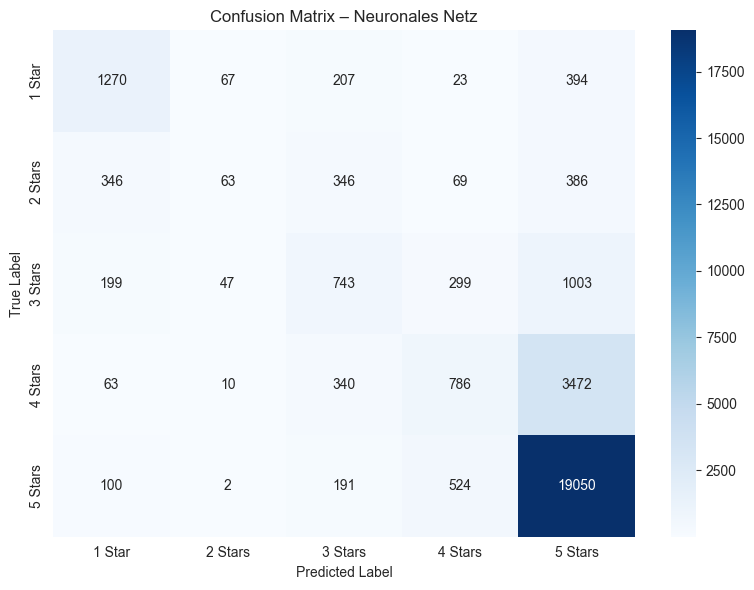

✓ Gespeichert: ..\results\neural\figures\confusion_matrix_neural.png


In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix – Neuronales Netz')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix_neural.png', dpi=150)
plt.show()
print(f"✓ Gespeichert: {FIGURES_DIR / 'confusion_matrix_neural.png'}")

### Confusion Matrix – Interpretation

**Struktur:**
- Zeilen = True Label (tatsächliche Klasse)
- Spalten = Predicted Label (vom Modell vorhergesagte Klasse)

**Für jede Klasse (Beispiel: "5 Stars"):**

**TP (True Positives) – Diagonale:** Korrekt als diese Klasse vorhergesagt.

**FP (False Positives) – Spalte (ohne Diagonale):** Fälschlicherweise als diese Klasse klassifiziert.

**FN (False Negatives) – Zeile (ohne Diagonale):** Gehört zu dieser Klasse, wurde aber falsch klassifiziert.

**TN (True Negatives):** Alles außerhalb der Zeile und Spalte dieser Klasse.

## 9. Ergebnisse speichern

In [18]:
# Metriken als JSON
results = {
    'accuracy': float(accuracy),
    'val_accuracy': float(val_accuracy),
    'confusion_matrix': conf_matrix.tolist(),
    'num_train_samples': len(y_train),
    'num_val_samples': len(y_val),
    'num_test_samples': len(y_test),
    'classes': CLASS_NAMES,
    'hyperparameters': {
        'hidden_units': HIDDEN_UNITS,
        'dropout_rate': DROPOUT_RATE,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'epochs_trained': len(history.history['loss']),
        'max_features': MAX_FEATURES,
        'min_df': MIN_DF,
        'max_df': MAX_DF,
        'ngram_range': list(NGRAM_RANGE),
        'stop_words': STOP_WORDS,
        'sublinear_tf': SUBLINEAR_TF
    }
}
with open(METRICS_DIR / 'neural_metrics.json', 'w') as f:
    json.dump(results, f, indent=2)

# CSV für Vergleiche
epochs_trained = len(history.history['loss'])
hyperparams_str = (
    f"hidden_units: {HIDDEN_UNITS} | dropout_rate: {DROPOUT_RATE} | "
    f"learning_rate: {LEARNING_RATE} | batch_size: {BATCH_SIZE} | "
    f"epochs_trained: {epochs_trained} | max_features: {MAX_FEATURES} | "
    f"min_df: {MIN_DF} | max_df: {MAX_DF} | ngram_range: {NGRAM_RANGE} | "
    f"stop_words: {STOP_WORDS} | sublinear_tf: {SUBLINEAR_TF}"
)
pd.DataFrame({
    'Model':           ['Neural Network'],
    'Accuracy':        [accuracy],
    'Val_Accuracy':    [val_accuracy],
    'Train_Samples':   [len(y_train)],
    'Test_Samples':    [len(y_test)],
    'Hyperparameters': [hyperparams_str]
}).to_csv(METRICS_DIR / 'neural_results.csv', index=False, sep=';')

model.save(MODEL_DIR / 'neural_model.keras')
with open(MODEL_DIR / 'neural_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print(f"✓ Metriken gespeichert in {METRICS_DIR}")
print(f"✓ Modell gespeichert in {MODEL_DIR}")

✓ Metriken gespeichert in ..\results\neural\metrics
✓ Modell gespeichert in ..\results\neural\models
